In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score


Linear Regression
MSE: 21.227484289611397
R²: 0.5841057656051312
Degree 2
MSE: 20.649054718307305
R²: 0.5954385038809804
Degree 3
MSE: 20.81794078857357
R²: 0.5921296453306659
Degree 4
MSE: 20.88841279063398
R²: 0.5907489400646382


/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


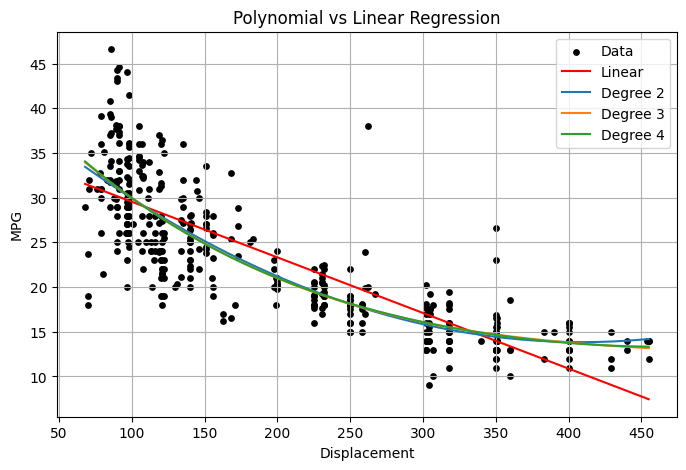

In [11]:
#Implement polynomial regression on the Auto MPG dataset to predict miles per gallon
#(MPG) based on engine displacement. Compare polynomial regression results with linear regression.
#Tasks:
#● Load and preprocess the dataset.
#● Implement polynomial regression of varying degrees.
#● Compare the polynomial regression models with linear regression using metrics such as MSE and R-squared.
#● Visualize the polynomial fit





url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url).dropna()

X = df[['displacement']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

degrees = [2, 3, 4]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=15, color="black", label="Data")

x_plot = np.linspace(X.min().values[0], X.max().values[0], 300).reshape(-1, 1)
plt.plot(x_plot, lr.predict(x_plot), color="red", label="Linear")

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    print(f"Degree {d}")
    print("MSE:", mean_squared_error(y_test, pred))
    print("R²:", r2_score(y_test, pred))

    model.fit(X, y)
    plt.plot(x_plot, model.predict(x_plot), label=f"Degree {d}")

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Polynomial vs Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import pandas as pd


df = pd.read_csv(url)

print(df.head())


  18.0   8   307.0      130.0      3504.      12.0   70  1\t"chevrolet chevelle malibu"
0  15.0   8   350.0      165.0      3693.      11...                                   
1  18.0   8   318.0      150.0      3436.      11...                                   
2  16.0   8   304.0      150.0      3433.      12...                                   
3  17.0   8   302.0      140.0      3449.      10...                                   
4  15.0   8   429.0      198.0      4341.      10...                                   


/tmp/ipykernel_19384/1067541855.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Linear Regression
MSE : 21.5261604508619
R2  : 0.6467421834257859

Polynomial Degree 2
MSE : 18.98735896326739
R2  : 0.688405510811562

Polynomial Degree 3
MSE : 18.921089414237827
R2  : 0.6894930357442587

Polynomial Degree 4
MSE : 18.917003034680853
R2  : 0.689560095800012


/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/thirdyr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


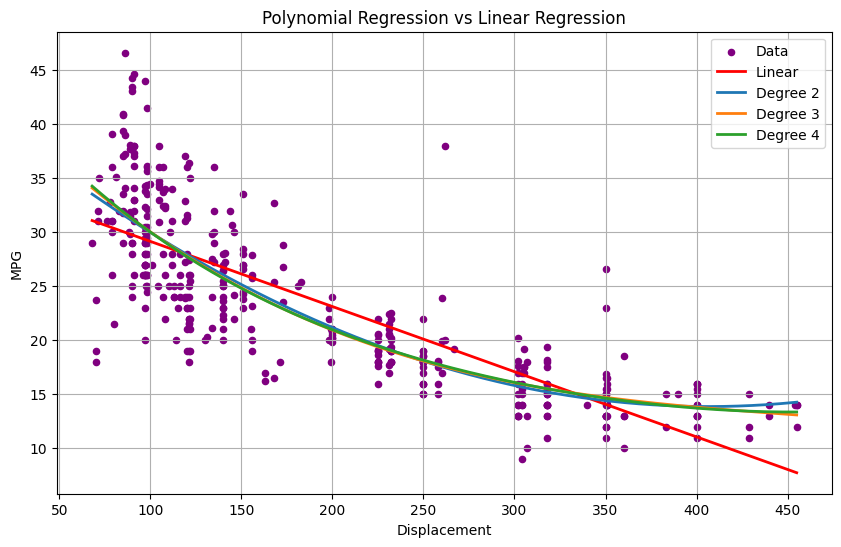

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score



columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    na_values="?",
    comment="\t"
)

df = df[["displacement", "mpg"]]
df = df.dropna()

X = df[["displacement"]]
y = df["mpg"]

linear = LinearRegression()
linear.fit(X, y)

y_linear = linear.predict(X)

print("Linear Regression")
print("MSE :", mean_squared_error(y, y_linear))
print("R2  :", r2_score(y, y_linear))

degrees = [2, 3, 4]

plt.figure(figsize=(10,6))

plt.scatter(X, y, color="purple", s=20, label="Data")

x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

plt.plot(
    x_plot,
    linear.predict(x_plot),
    color="red",
    linewidth=2,
    label="Linear"
)

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    print("\nPolynomial Degree", d)
    print("MSE :", mean_squared_error(y, y_pred))
    print("R2  :", r2_score(y, y_pred))

    x_poly = poly.transform(x_plot)

    plt.plot(
        x_plot,
        model.predict(x_poly),
        linewidth=2,
        label=f"Degree {d}"
    )

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Polynomial Regression vs Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score



columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    na_values="?",
    comment="\t"
)

df = df[["displacement", "mpg"]]
df = df.dropna()

X = df[["displacement"]]
y = df["mpg"]

linear = LinearRegression()
linear.fit(X, y)

y_linear = linear.predict(X)

print("Linear Regression")
print("MSE :", mean_squared_error(y, y_linear))
print("R2  :", r2_score(y, y_linear))

degrees = [2, 3, 4]

plt.figure(figsize=(10,6))

plt.scatter(X, y, color="purple", s=20, label="Data")

x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

plt.plot(
    x_plot,
    linear.predict(x_plot),
    color="red",
    linewidth=2,
    label="Linear"
)

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    print("\nPolynomial Degree", d)
    print("MSE :", mean_squared_error(y, y_pred))
    print("R2  :", r2_score(y, y_pred))

    x_poly = poly.transform(x_plot)

    plt.plot(
        x_plot,
        model.predict(x_poly),
        linewidth=2,
        label=f"Degree {d}"
    )

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Polynomial Regression vs Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'url' is not defined